# Полный EDA: датасет профилей поглощения He I 10830 Å

Разведочный анализ 614 прогонов 3D-гидродинамической модели атмосферы.
Цели:
1. составить **полную опись параметров** `parameters.txt` — что варьируется,
   что фиксировано, что можно использовать как дополнительные таргеты/признаки;
2. понять **структуру данных**: планеты, сетки, аномалии;
3. изучить **связь формы профиля с параметрами** и наглядно показать
   **вырожденность** обратной задачи;
4. проверить, **какие ещё параметры** восстановимы из профиля.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "new_dataset_V3"
GRID = np.arange(-5.0, 5.0 + 1e-9, 0.1)

records, profiles, raw_grids = [], [], []
for name in sorted(os.listdir(DATA_DIR)):
    path = os.path.join(DATA_DIR, name)
    if not os.path.isdir(path):
        continue
    params = {"dirname": name}
    with open(os.path.join(path, "parameters.txt")) as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 2:
                params[parts[0]] = parts[1]
    arr = np.loadtxt(os.path.join(path, "Absorption.dat"), skiprows=1)
    params["_n_points"] = arr.shape[0]
    params["_v_min"], params["_v_max"] = arr[0, 0], arr[-1, 0]
    records.append(params)
    profiles.append(np.interp(GRID, arr[:, 0], arr[:, 1], left=0.0, right=0.0))

df = pd.DataFrame(records)
profiles = np.array(profiles)
print("прогонов:", len(df), " колонок parameters.txt:", df.shape[1] - 4)

прогонов: 614  колонок parameters.txt: 35


## 1. Опись всех параметров `parameters.txt`

Перебираем **все** ключи: сколько уникальных значений, диапазон, варьируется ли.

In [2]:
rows = []
for col in df.columns:
    if col.startswith("_") or col == "dirname":
        continue
    vals = df[col]
    try:
        num = vals.astype(float)
        rows.append({"параметр": col, "уникальных": num.nunique(),
                     "min": num.min(), "max": num.max(),
                     "варьируется": "ДА" if num.nunique() > 1 else "нет"})
    except (ValueError, TypeError):
        rows.append({"параметр": col, "уникальных": vals.nunique(),
                     "min": "-", "max": "-",
                     "варьируется": "ДА" if vals.nunique() > 1 else "нет",})
inventory = pd.DataFrame(rows).sort_values("уникальных", ascending=False)
inventory

,параметр,уникальных,min,max,варьируется
16,Msw,177,100000000000.0,99000000000000.0,ДА
12,Helium,68,0.001022,0.300022,ДА
3,XUVInt,40,1.0,60.0,ДА
17,Tmax,12,70.0,1000.0,ДА
2,PName,4,-,-,ДА
25,Minor1,3,306.0,308.0,ДА
26,Minor2,3,307.0,311.0,ДА
27,Minor3,3,308.0,320.0,ДА
21,Bdo,3,0.5,2.0,ДА
1,Rmax,3,150.0,200.0,ДА


**Выводы по описи:**

* **Таргеты задачи** — `XUVInt` (40 значений), `Msw` (177), `Helium` (68),
  `H2a` (2): варьируются сильнее всего, это основная сетка эксперимента.
* **`PName`** — планета (WASP-107b / WASP-69b / WASP-52b + служебные метки
  у старых прогонов): категориальный скрытый фактор, задаёт геометрию системы.
* **Служебные параметры счёта** (`Tmax`, `Tstart`, `DtSave`, `MaxFlux`, ...)
  тоже кое-где меняются — но это настройки численного счёта, а не физика:
  использовать их как таргеты нельзя, как признаки — недоступны на инференсе.
* Остальная физика (`Vsw`, `Rsw`, `Rbase`, `TemBase`, ...) **фиксирована** —
  датасет не позволяет изучить её влияние.

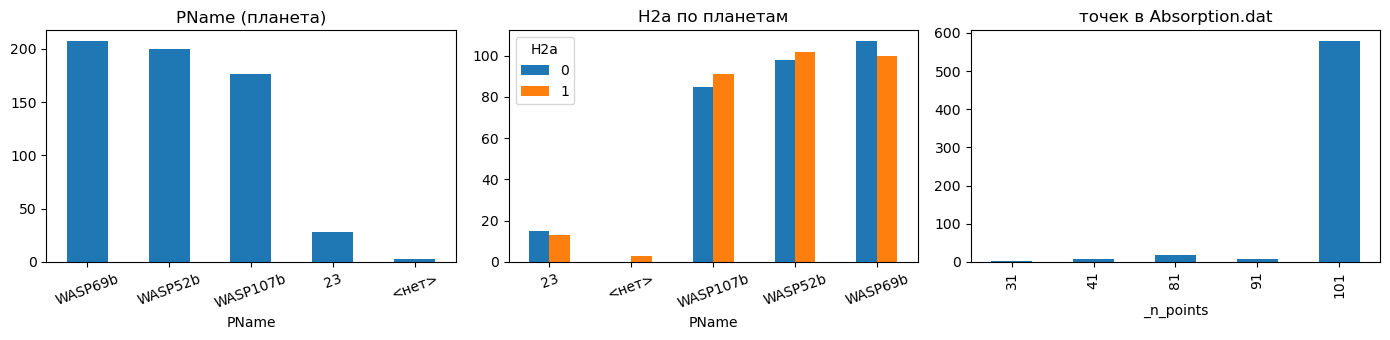

нестандартные сетки скоростей:
_n_points  _v_min  _v_max
31         -4.0    -1.0       1
41         -4.0     4.0       8
81         -4.0     4.0      19
91         -5.0     4.0       8
dtype: int64


In [3]:
# распределение планет и связь с H2a
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
pn = df["PName"].fillna("<нет>")
pn.value_counts().plot.bar(ax=axes[0], rot=20)
axes[0].set_title("PName (планета)")
pd.crosstab(pn, df["H2a"]).plot.bar(ax=axes[1], rot=20)
axes[1].set_title("H2a по планетам")
df["_n_points"].value_counts().sort_index().plot.bar(ax=axes[2])
axes[2].set_title("точек в Absorption.dat")
plt.tight_layout()
plt.show()
print("нестандартные сетки скоростей:")
print(df.loc[df["_n_points"] != 101, ["dirname", "_n_points", "_v_min", "_v_max"]]
      .groupby(["_n_points", "_v_min", "_v_max"]).size())

**Аномалии структуры:** 13 папок со старым именованием `X...` (без `XUV`),
28 прогонов с `PName=23` и 3 без `PName`; 36 файлов на нестандартных сетках,
один (`31 точка, [-4,-1]`) — фактически битый. Всё это надо учитывать при
загрузке (мы интерполируем на общую сетку и отбрасываем битый прогон).

## 2. Покрытие пространства параметров

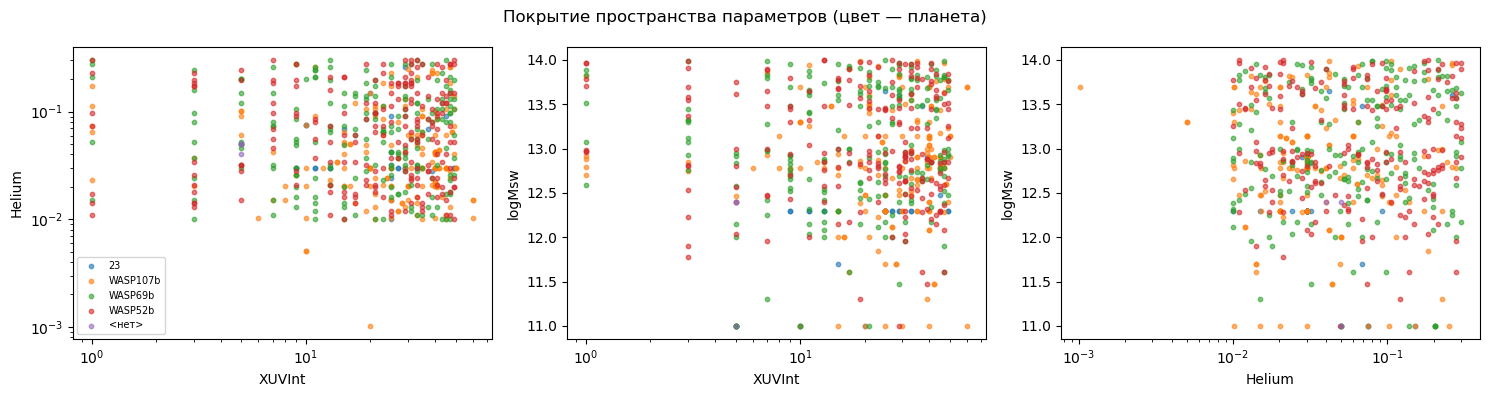

In [4]:
t = df.copy()
for c in ["XUVInt", "Helium", "Msw"]:
    t[c] = t[c].astype(float)
t["logMsw"] = np.log10(t["Msw"])
t["H2a"] = t["H2a"].astype(float)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
planets = pn.unique()
colors = dict(zip(planets, plt.cm.tab10.colors))
pairs = [("XUVInt", "Helium"), ("XUVInt", "logMsw"), ("Helium", "logMsw")]
for ax, (a, b) in zip(axes, pairs):
    for p in planets:
        m = (pn == p).values
        ax.scatter(t.loc[m, a], t.loc[m, b], s=10, alpha=0.6,
                   color=colors[p], label=p)
    ax.set_xlabel(a)
    ax.set_ylabel(b)
    if a != "logMsw":
        ax.set_xscale("log")
    if b == "Helium":
        ax.set_yscale("log")
axes[0].legend(fontsize=7)
plt.suptitle("Покрытие пространства параметров (цвет — планета)")
plt.tight_layout()
plt.show()

Сетка не регулярная и не одинаковая по планетам: у каждой планеты своя
подвыборка параметров, значения коррелированы с планетой. Модель, определив
планету по форме профиля, автоматически сужает диапазон правдоподобных
параметров — одна из причин, почему знание планеты полезно.

## 3. Форма профиля и параметры

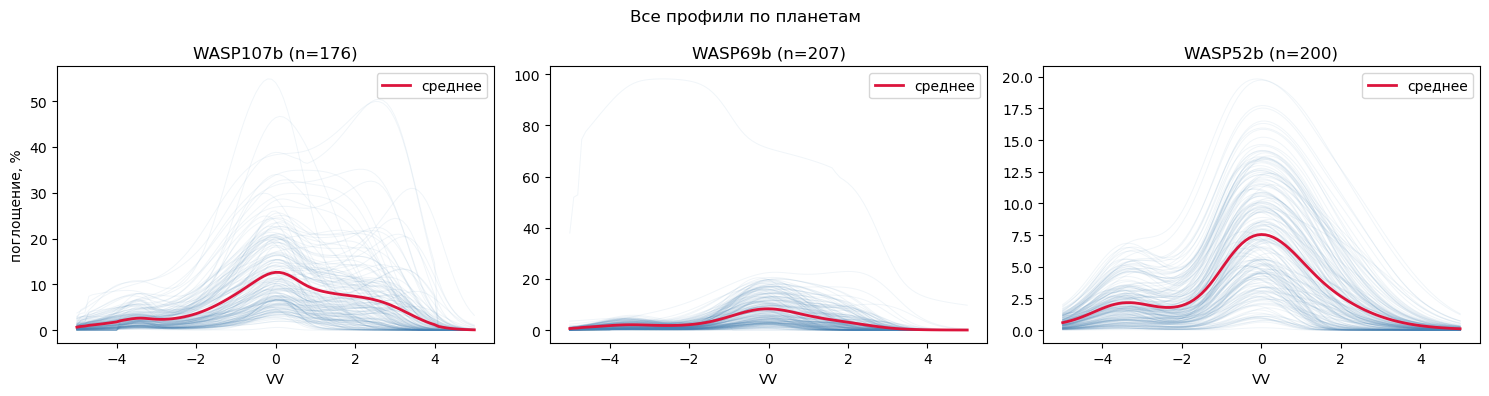

In [5]:
log_prof = np.log10(np.clip(profiles, 1e-7, None))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
main = [p for p in planets if str(p).startswith("WASP")]
for ax, p in zip(axes, main):
    m = (pn == p).values
    sub = profiles[m]
    ax.plot(GRID, 100 * sub.T, color="steelblue", alpha=0.08, lw=0.7)
    ax.plot(GRID, 100 * sub.mean(0), color="crimson", lw=2, label="среднее")
    ax.set_title(f"{p} (n={m.sum()})")
    ax.set_xlabel("VV")
    ax.legend()
axes[0].set_ylabel("поглощение, %")
plt.suptitle("Все профили по планетам")
plt.tight_layout()
plt.show()

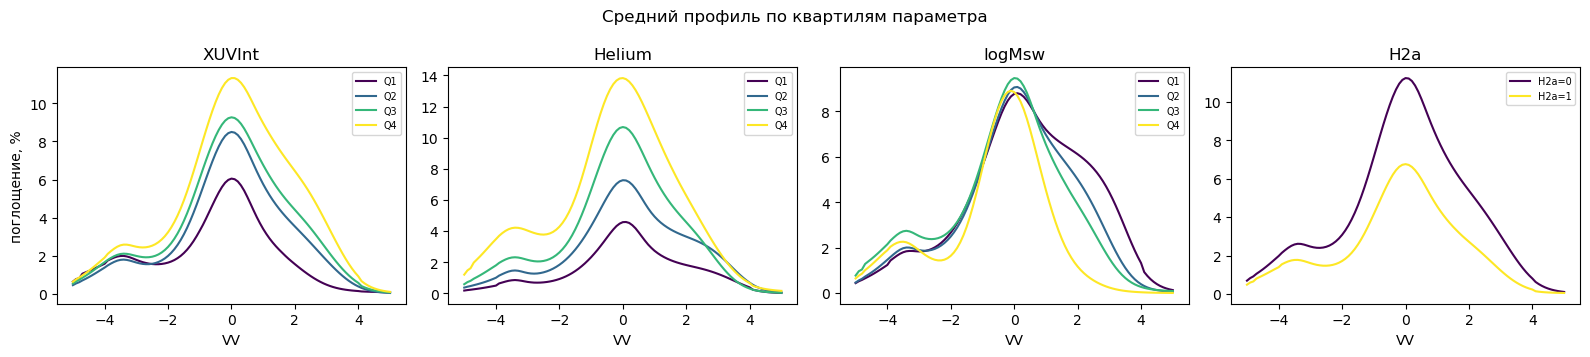

In [6]:
# средние профили по квартилям каждого таргета: как параметр «двигает» форму
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
specs = [("XUVInt", t["XUVInt"]), ("Helium", t["Helium"]),
         ("logMsw", t["logMsw"]), ("H2a", t["H2a"])]
for ax, (name, v) in zip(axes, specs):
    if name == "H2a":
        groups = [(v == 0, "H2a=0"), (v == 1, "H2a=1")]
    else:
        qs = np.quantile(v, [0, 0.25, 0.5, 0.75, 1.0])
        groups = [((v >= qs[k]) & (v <= qs[k + 1]), f"Q{k + 1}")
                  for k in range(4)]
    for k, (m, lbl) in enumerate(groups):
        ax.plot(GRID, 100 * profiles[np.asarray(m)].mean(0),
                color=plt.cm.viridis(k / max(len(groups) - 1, 1)), label=lbl)
    ax.set_title(name)
    ax.set_xlabel("VV")
    ax.legend(fontsize=7)
axes[0].set_ylabel("поглощение, %")
plt.suptitle("Средний профиль по квартилям параметра")
plt.tight_layout()
plt.show()

Читается физика: рост `XUVInt` и `Helium` увеличивает амплитуду (и XUV —
ширину), рост `Msw` смещает пик в синюю сторону (ветер сносит газ к
наблюдателю), `H2a` слегка перераспределяет ядро/крылья.

## 4. PCA профилей: скрытая структура

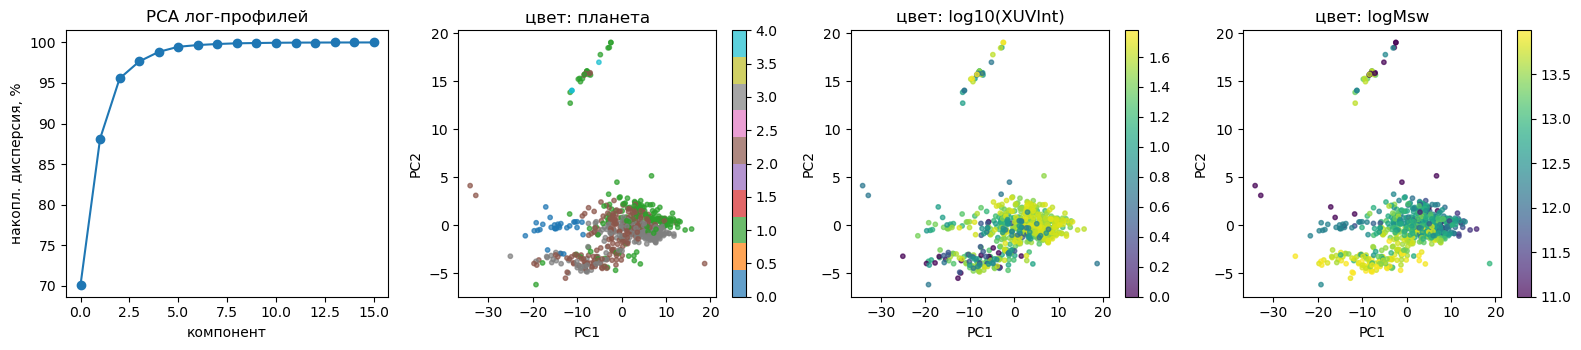

In [7]:
mu = log_prof.mean(0)
U, S, Vt = np.linalg.svd(log_prof - mu, full_matrices=False)
Z = (log_prof - mu) @ Vt[:16].T
evr = S**2 / (S**2).sum()

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
axes[0].plot(np.cumsum(evr[:16]) * 100, marker="o")
axes[0].set_xlabel("компонент")
axes[0].set_ylabel("накопл. дисперсия, %")
axes[0].set_title("PCA лог-профилей")
for ax, (name, v, kw) in zip(axes[1:], [
        ("планета", pd.factorize(pn)[0], dict(cmap="tab10")),
        ("log10(XUVInt)", np.log10(t["XUVInt"]), dict(cmap="viridis")),
        ("logMsw", t["logMsw"], dict(cmap="viridis"))]):
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=v, s=10, alpha=0.7, **kw)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"цвет: {name}")
    plt.colorbar(sc, ax=ax)
plt.tight_layout()
plt.show()

Два первых компонента объясняют ~90% дисперсии; в плоскости PC1–PC2 планеты
образуют пересекающиеся, но различимые облака, а параметры задают плавные
градиенты. Профиль содержит информацию и о планете, и о параметрах.

## 5. Вырожденность (XUV, Helium)

Главная сложность задачи: находим пары прогонов с **почти одинаковыми
профилями**, но **сильно разными параметрами**.

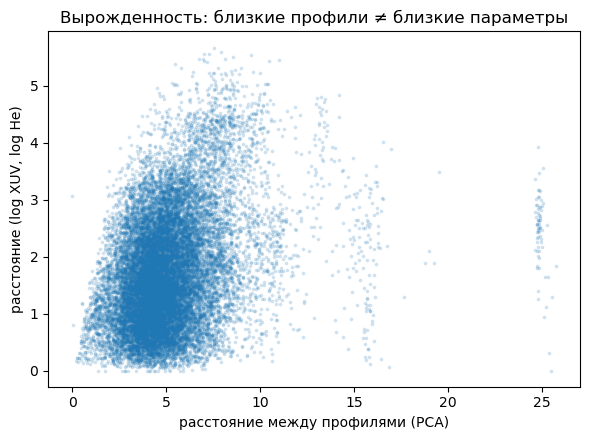

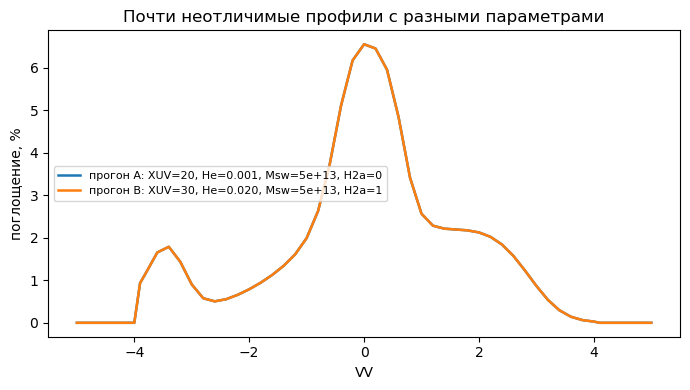

In [8]:
from scipy.spatial.distance import cdist

zs = Z / Z.std(0)
Dp = cdist(zs, zs)                       # расстояние профилей
lx = np.log10(t["XUVInt"].values)
lh = np.log10(t["Helium"].values)
par = np.stack([lx / lx.std(), lh / lh.std()], 1)
Dq = cdist(par, par)                     # расстояние (XUV, He)

iu = np.triu_indices(len(df), 1)
plt.figure(figsize=(6, 4.5))
sel = np.random.default_rng(0).choice(len(iu[0]), 20000, replace=False)
plt.scatter(Dp[iu][sel], Dq[iu][sel], s=3, alpha=0.15)
plt.xlabel("расстояние между профилями (PCA)")
plt.ylabel("расстояние (log XUV, log He)")
plt.title("Вырожденность: близкие профили ≠ близкие параметры")
plt.tight_layout()
plt.show()

# самая показательная пара
mask = (Dp[iu] < np.quantile(Dp[iu], 0.001))
best = np.argmax(Dq[iu] * mask)
i, j = iu[0][best], iu[1][best]
plt.figure(figsize=(7, 4))
for k, lbl in [(i, "прогон A"), (j, "прогон B")]:
    r = t.iloc[k]
    plt.plot(GRID, 100 * profiles[k], lw=1.8,
             label=f"{lbl}: XUV={r.XUVInt:g}, He={r.Helium:.3f}, "
                   f"Msw={r.Msw:.0e}, H2a={int(r.H2a)}")
plt.xlabel("VV")
plt.ylabel("поглощение, %")
plt.title("Почти неотличимые профили с разными параметрами")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

В левом нижнем углу первого графика видно облако пар: профили почти
совпадают, а параметры различаются в разы. Любое решение с одним ответом
упирается в этот предел — отсюда подход «несколько кандидатов + ранжирование».

## 6. Что ещё восстановимо из профиля?

Перебираем все варьирующиеся параметры (не только 4 таргета) и смотрим,
насколько каждый предсказуем из профиля (быстрый GradientBoosting на PCA-16,
5-fold CV).

In [9]:
import warnings
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, KFold

# ВАЖНО: папки отсортированы по имени, поэтому фолды нужно перемешивать,
# иначе train и test попадают в разные области сетки параметров
cv = KFold(n_splits=5, shuffle=True, random_state=0)
X = Z  # PCA-16 как компактные признаки профиля
report = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for col in inventory.loc[inventory["варьируется"] == "ДА", "параметр"]:
        vals = df[col]
        try:
            y = vals.astype(float).values
            if np.unique(y).size == 2:
                minority = np.bincount((y == y.max()).astype(int)).min()
                if minority < 10:
                    report.append((col, "классификация",
                                   f"редкий класс (n={minority}) — не оценить"))
                    continue
                score = cross_val_score(GradientBoostingClassifier(random_state=0),
                                        X, (y == y.max()).astype(int), cv=cv,
                                        scoring="roc_auc").mean()
                report.append((col, "классификация", f"ROC-AUC={score:.3f}"))
            else:
                yl = np.log10(np.clip(y, 1e-12, None)) if y.min() > 0 else y
                score = cross_val_score(GradientBoostingRegressor(random_state=0),
                                        X, yl, cv=cv, scoring="r2").mean()
                report.append((col, "регрессия(log)", f"R2={score:.3f}"))
        except (ValueError, TypeError):
            codes, _ = pd.factorize(vals.fillna("<нет>"))
            score = cross_val_score(GradientBoostingClassifier(random_state=0),
                                    X, codes, cv=cv, scoring="accuracy").mean()
            report.append((col, "классификация", f"accuracy={score:.3f}"))
pd.DataFrame(report, columns=["параметр", "задача", "качество (5-fold CV)"])

,параметр,задача,качество (5-fold CV)
0,Msw,регрессия(log),R2=0.722
1,Helium,регрессия(log),R2=0.800
2,XUVInt,регрессия(log),R2=0.759
3,Tmax,регрессия(log),R2=0.354
4,PName,классификация,accuracy=0.904
5,Minor1,классификация,accuracy=0.987
6,Minor2,классификация,accuracy=0.990
7,Minor3,классификация,accuracy=0.990
8,Bdo,классификация,accuracy=0.982
9,Rmax,регрессия(log),R2=0.561


**Интерпретация:**

* `PName` (планета) предсказывается по профилю почти безошибочно — планета
  «зашита» в форму линии; это оправдывает двухступенчатые схемы
  (планета → параметры) и работу ранкера.
* `Msw`/`logMsw` и `H2a` восстановимы отлично, `XUVInt` и `Helium` — лишь
  частично (вырожденность, см. раздел 5).
* Служебные параметры счёта (`Tmax` и пр.) отчасти «предсказуемы» лишь потому,
  что коррелируют с планетой/сеткой эксперимента — физического смысла в их
  предсказании нет, в таргеты их брать не стоит.

## 7. Главные выводы EDA

1. Реально варьируются 4 таргета + планета; остальная физика фиксирована.
2. У каждой планеты своя подсетка параметров — планета и параметры
   коррелированы; форма профиля выдаёт планету почти со 100% точностью.
3. 36 прогонов на нестандартных сетках (интерполировать), 1 битый (выбросить),
   13 папок со старым именованием.
4. Профиль хорошо кодирует `Msw` (сдвиг пика) и `H2a` (ядро/крылья),
   но пара (`XUVInt`, `Helium`) вырождена — есть пары почти одинаковых
   профилей с разными параметрами; это фундаментальный предел точности
   одиночного ответа и мотивация для multi-candidate подходов.